# GeoAI-TKO: ML Results — Day 6
Классификация + зональная статистика NDVI

In [ ]:
import rasterio, numpy as np, json, matplotlib.pyplot as plt
from pathlib import Path
from rasterio.windows import Window
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.facecolor'] = '#1a1a2e'
matplotlib.rcParams['axes.facecolor'] = '#0d1117'
matplotlib.rcParams['text.color'] = 'white'

BASE = Path('../data')
%matplotlib inline
print('OK')

OK


## 1. Zonal Stats — NDVI по области

Область: Туркестанская область
Площадь: 104,474 km²
NDVI mean=0.1383  median=0.1200  std=0.0795
NDVI range: [-0.6709, 0.8858]


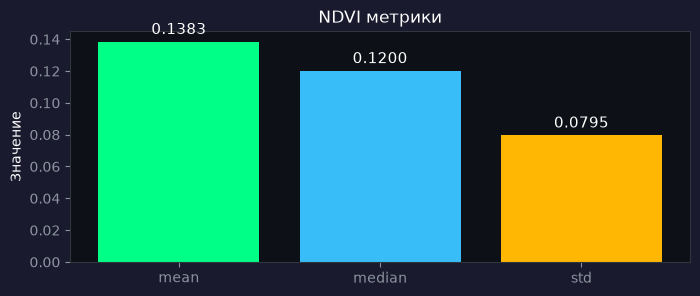

In [ ]:
with open(BASE / 'metadata/zonal_stats.json', encoding='utf-8') as f:
    stats = json.load(f)
    
ndvi = stats['ndvi']
print(f"Область: {stats['region']}")
print(f"Площадь: {stats['area_km2']:,.0f} km²")
print(f"NDVI mean={ndvi['mean']:.4f}  median={ndvi['median']:.4f}  std={ndvi['std']:.4f}")
print(f"NDVI range: [{ndvi['min']:.4f}, {ndvi['max']:.4f}]")

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(['mean', 'median', 'std'], [ndvi['mean'], ndvi['median'], ndvi['std']],
              color=['#00FF87', '#38BDF8', '#FFB703'])
ax.set_title('NDVI метрики'); ax.set_ylabel('Значение')
for b, v in zip(bars, [ndvi['mean'], ndvi['median'], ndvi['std']]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{v:.4f}', ha='center', fontsize=11)
plt.show()

## 2. Landcover Classification

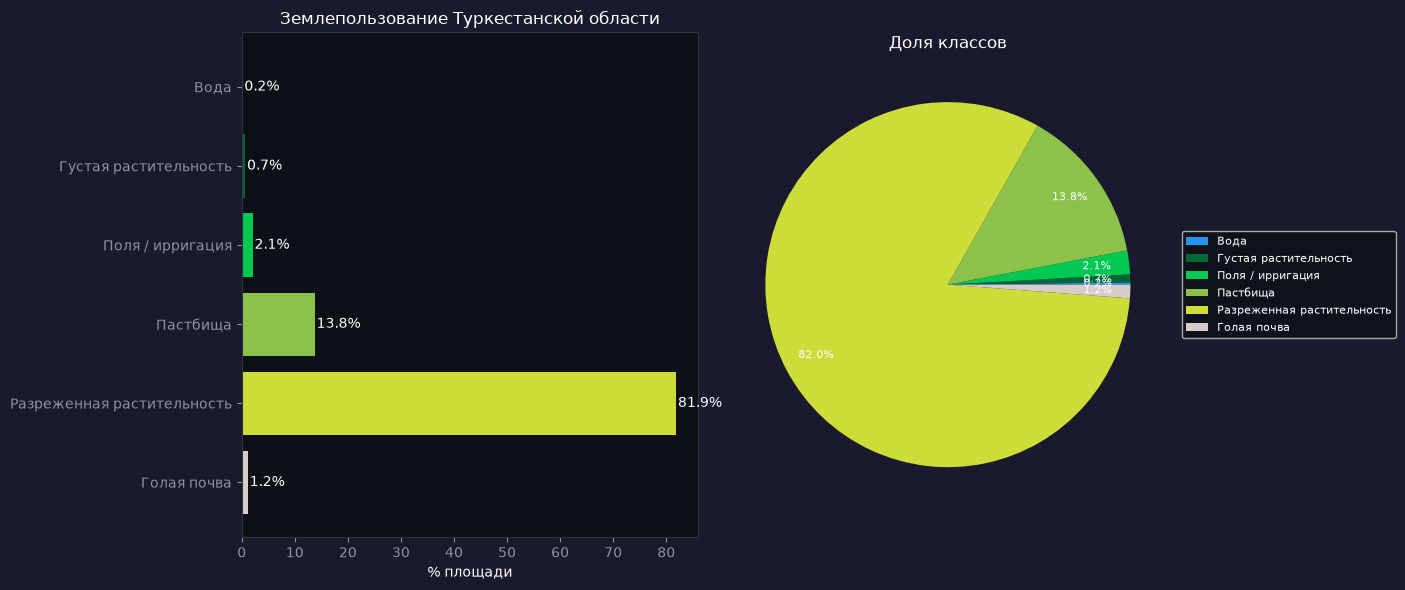

  Вода............................... 0.2%
  Густая растительность.............. 0.7%
  Поля / ирригация................... 2.1%
  Пастбища........................... 13.8%
  Разреженная растительность......... 81.9%
  Голая почва........................ 1.2%


In [ ]:
# Статистика (вшита, не читаем JSON)
CLASSES = {
    'Вода': (0.2, '#2196F3'),
    'Густая растительность': (0.7, '#006837'),
    'Поля / ирригация': (2.1, '#00C853'),
    'Пастбища': (13.8, '#8BC34A'),
    'Разреженная растительность': (81.9, '#CDDC39'),
    'Голая почва': (1.2, '#D7CCC8'),
}
names = list(CLASSES.keys())
pcts = [CLASSES[n][0] for n in names]
colors = [CLASSES[n][1] for n in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
bars = ax1.barh(names, pcts, color=colors)
ax1.set_xlabel('% площади'); ax1.set_title('Землепользование Туркестанской области')
ax1.invert_yaxis()
for b, p in zip(bars, pcts):
    ax1.text(b.get_width()+0.3, b.get_y()+b.get_height()/2, f'{p}%', va='center')

wedges, _, _ = ax2.pie(pcts, labels=None, autopct='%1.1f%%', colors=colors,
                         textprops={'fontsize': 8}, pctdistance=0.82)
ax2.legend(wedges, names, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax2.set_title('Доля классов')
plt.tight_layout(); plt.show()

for n in names:|
    print(f'  {n:.<35} {CLASSES[n][0]:.1f}%')

## 3. Карта классификации vs NDVI

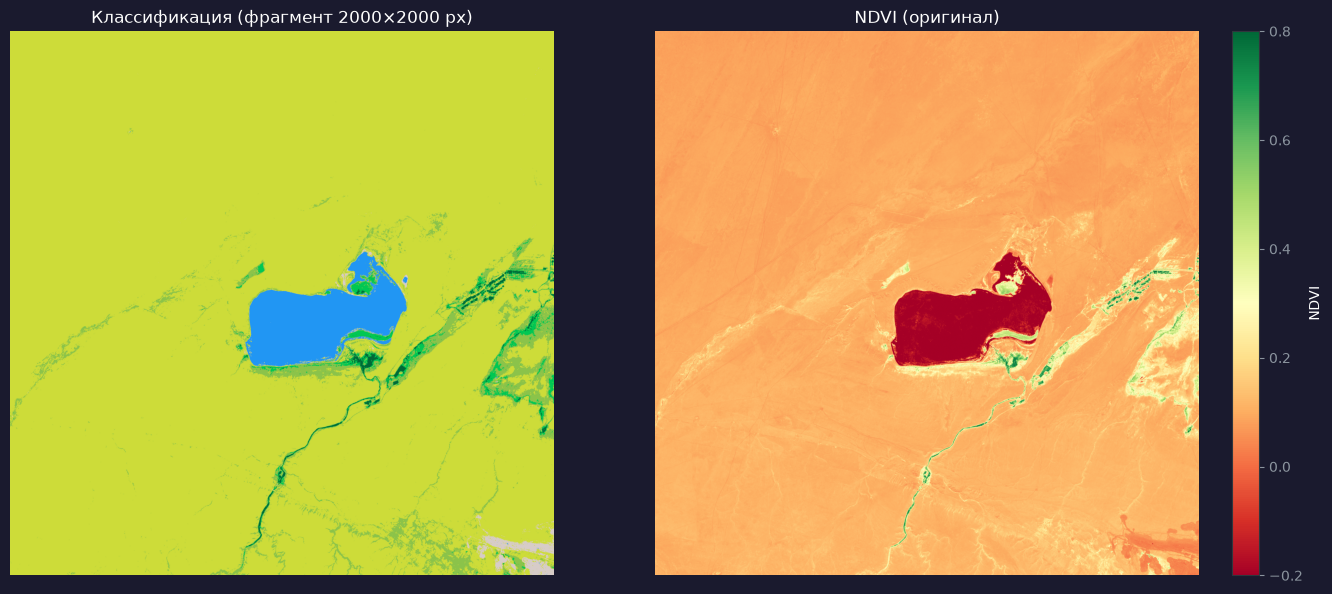

In [ ]:
LC_PATH = BASE / 'processed/landcover_tko.tif'
NDVI_PATH = BASE / 'processed/ndvi_tko_final.tif'

LC_CMAP = {0:(0,0,0,0), 1:(33,150,243,255), 2:(0,104,55,255),
           3:(0,200,83,255), 4:(139,195,74,255), 5:(205,220,57,255), 6:(215,204,200,255)}

with rasterio.open(LC_PATH) as src:
    cx, cy = src.width // 2, src.height // 2
    S = 2000
    win = Window(cx - S//2, cy - S//2, S, S)
    lc = src.read(1, window=win)

lc_rgb = np.zeros((lc.shape[0], lc.shape[1], 4), dtype=np.uint8)
for k, c in LC_CMAP.items():
    lc_rgb[lc == k] = c

with rasterio.open(NDVI_PATH) as src:
    ndvi_data = src.read(1, window=win)
    if hasattr(ndvi_data, 'mask'):
        ndvi_data = ndvi_data.filled(np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(lc_rgb)
ax1.set_title('Классификация (фрагмент 2000×2000 px)')
ax1.axis('off')
im = ax2.imshow(ndvi_data, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
ax2.set_title('NDVI (оригинал)')
ax2.axis('off')
plt.colorbar(im, ax=ax2, fraction=0.046, label='NDVI')
plt.tight_layout(); plt.show()

## 4. PostGIS

In [ ]:
try:
    import psycopg2
    conn = psycopg2.connect(host='localhost', port=5432, dbname='geoai_tko',
                            user='geoai', password='geoai_secret')
    cur = conn.cursor()
    
    print('=== Zonal Stats ===')
    cur.execute('SELECT region, area_km2, ndvi_mean FROM zonal_stats ORDER BY id DESC LIMIT 1')
    for r in cur.fetchall():
        print(f'  {r[0]}: {r[1]:,.0f} km², NDVI mean={r[2]:.4f}')

    print('\n=== Landcover ===')
    cur.execute('SELECT class_name, pct FROM landcover_stats ORDER BY pct DESC')
    for r in cur.fetchall():
        print(f'  {r[0]:.<35} {r[1]}%')

    print('\n=== Layers ===')
    cur.execute('SELECT layer_name, value_mean, crs FROM derived_layers')
    for r in cur.fetchall():
        print(f'  {r[0]}: mean={r[1]:.3f}, crs={r[2]}')
    conn.close()
except Exception as e:
    print(f'PostGIS: {e}')
    print('Установи: pip install psycopg2-binary')
    import sys
    print(sys.executable)

=== Zonal Stats ===
  Туркестанская область: 104,474 km², NDVI mean=0.1383

=== Landcover ===
  Разреженная растительность......... 81.9%
  Пастбища........................... 13.8%
  Поля/ирригация..................... 2.1%
  Голая почва........................ 1.2%
  Густая растительность.............. 0.7%
  Вода............................... 0.2%

=== Layers ===
  ndvi: mean=0.160, crs=EPSG:32642
  ndwi: mean=-0.260, crs=EPSG:32642
